In [1]:
# LES PACKAGES
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from scipy.sparse import hstack
from sklearn.preprocessing import StandardScaler
import nltk
from nltk.corpus import stopwords, wordnet
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
from wordcloud import WordCloud
from sklearn.utils import resample
from nltk.stem import WordNetLemmatizer 
import pickle

In [113]:
# LECTURE DE LA BASE SOURCE
data=pd.read_excel("repertoire_entreprise_2022.xlsx", dtype = {'SYSCOA1': str, 'NAEMAS': str}, sheet_name=0)
data['SYSCOA1'] = data['SYSCOA1'].astype('category')
data['NAEMAS'] = data['NAEMAS'].astype('category')
data.head()

,CUCI,RAISON_SOCIALE,DESIGNATION_PRECISE_ACTIVITE,FORME_JURIDIQUE,REGIME_JURIDIQUE,SYSCOA1,SYSCOA2,NAEMA1,NAEMA_rev1,NOPEMA1,NOPEMA_rev1,REGIONS,VILLES,NAEMAS
0,000130O,BOULANGERIE JALAL (MARWAN ABDEL AL),BOULANGERIE,8,IND,11001,NaN,15.71,10.71,15.71.0,10.71.0,DAKAR,DAKAR,F00060
1,000140B,GIE PADS,COMMERCE GENERAL,6,GIE,31003,NaN,NaN,NaN,NaN,NaN,DAKAR,DAKAR,N00030
2,000150L,AFRICA INFORMATION DE L'ELITE SA,VENTE DE CARTES POSTALES (EX-EDITION),1,SA,31003,38003.0,NaN,NaN,22.11.1,NaN,DAKAR,DAKAR,Q00050
3,000440C,MAKE SUARL,SERVICE,11,SUARL,038003,NaN,NaN,NaN,NaN,NaN,DAKAR,DAKAR,N00020
4,000450M,FILAO'PTIC,OPTICIEN,1,SA,26002,NaN,33.00,26.30,33.00.4,26.30.2,DAKAR,DAKAR,J00140


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25643 entries, 0 to 25642
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   CUCI                          25643 non-null  object  
 1   RAISON_SOCIALE                25643 non-null  object  
 2   DESIGNATION_PRECISE_ACTIVITE  24787 non-null  object  
 3   FORME_JURIDIQUE               17663 non-null  object  
 4   REGIME_JURIDIQUE              18672 non-null  object  
 5   SYSCOA1                       25643 non-null  category
 6   SYSCOA2                       4656 non-null   float64 
 7   NAEMA1                        7130 non-null   object  
 8   NAEMA_rev1                    11049 non-null  object  
 9   NOPEMA1                       7057 non-null   object  
 10  NOPEMA_rev1                   5522 non-null   object  
 11  REGIONS                       25642 non-null  object  
 12  VILLES                        24045 non-null  

# <b> DISTRIBUTION DES CLASSES DE LA VARIABLE CIBLE "NAEMAS"</b>

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\categorical.py:253: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


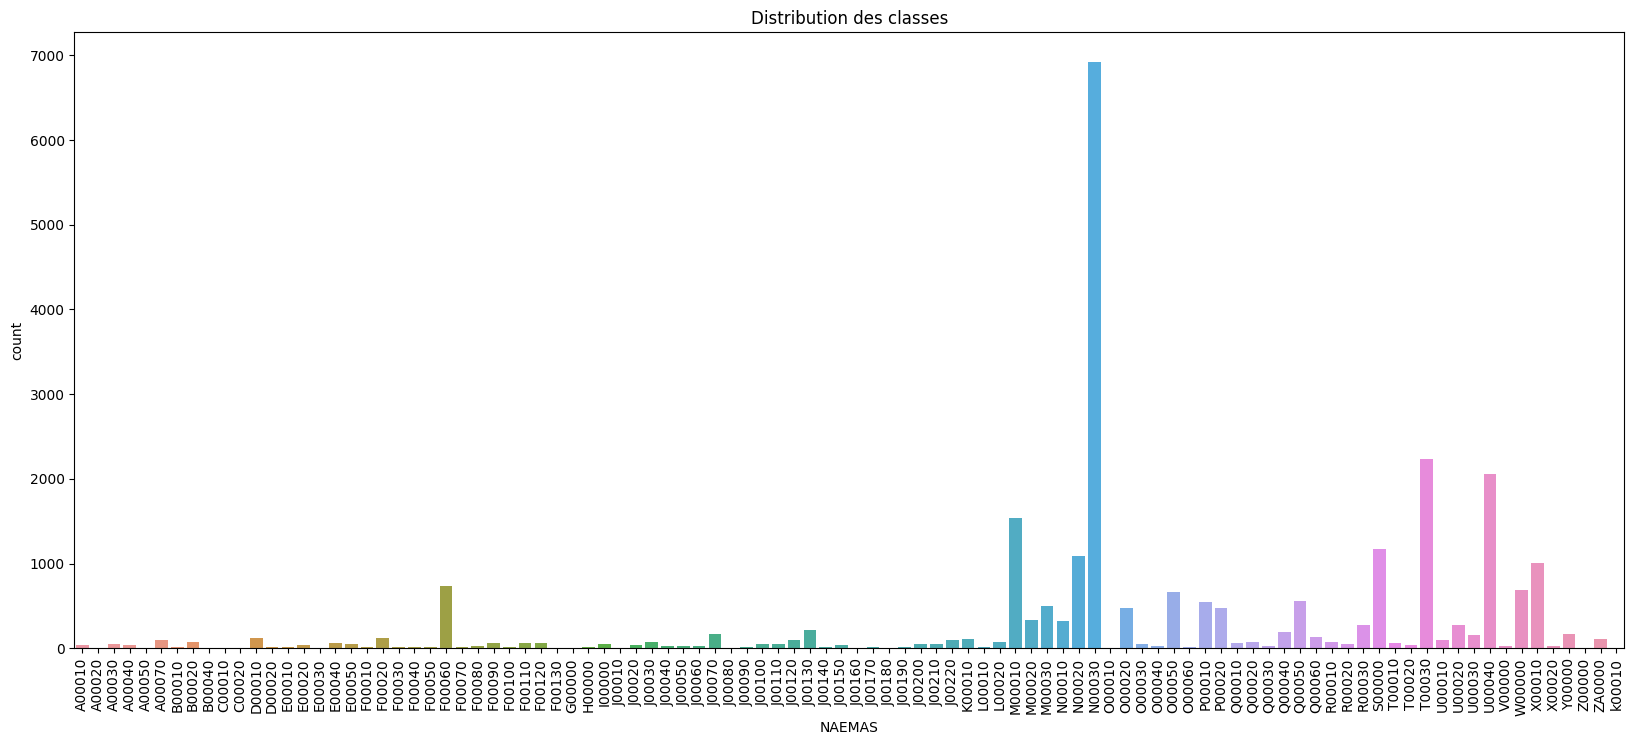

In [4]:
plt.figure(figsize=(20, 8))
sns.countplot(x='NAEMAS', data=data)
plt.title('Distribution des classes')
plt.xticks(rotation=90)
plt.show()

<b>CE GRAPHIQUE MONTRE QUE LES CLASSES DE LA VARIABLE NAEMAS SONT TRES DESEQUILIBREES </b>

# <b> SELECTION DES VARIABLES EN JEU </b>

In [116]:
df=data[["DESIGNATION_PRECISE_ACTIVITE","SYSCOA1","NAEMAS"]]
df.head()

,DESIGNATION_PRECISE_ACTIVITE,SYSCOA1,NAEMAS
0,BOULANGERIE,11001,F00060
1,COMMERCE GENERAL,31003,N00030
2,VENTE DE CARTES POSTALES (EX-EDITION),31003,Q00050
3,SERVICE,038003,N00020
4,OPTICIEN,26002,J00140


# <b> INSPECTION DES VALEURS MANQUANTES </b>

In [6]:
# Affichage des taux de valeurs manquantes par variable 
taux_manquantes = df.isnull().mean() * 100
print("Taux de valeurs manquantes par variable (%):")
print(taux_manquantes)
print("\n")
df.isnull().sum()

Taux de valeurs manquantes par variable (%):
DESIGNATION_PRECISE_ACTIVITE    3.338143
SYSCOA1                         0.000000
NAEMAS                          0.019498
dtype: float64




DESIGNATION_PRECISE_ACTIVITE    856
SYSCOA1                           0
NAEMAS                            5
dtype: int64

LES TAUX DE VALEURS MANQUANTES SONT TRES FAIBLES COMPARES A LA TAILLE DE LA BASE

###### Verification de chaque groupe NAEMAS

In [114]:
naemas = data.groupby('NAEMAS').apply(lambda x: x.isnull().sum().sum())
naemas.head(30)

C:\Users\hp\AppData\Local\Temp\ipykernel_26608\181008296.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  naemas = data.groupby('NAEMAS').apply(lambda x: x.isnull().sum().sum())
C:\Users\hp\AppData\Local\Temp\ipykernel_26608\181008296.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  naemas = data.groupby('NAEMAS').apply(lambda x: x.isnull().sum().sum())


NAEMAS
A00010     138
A00020      20
A00030     192
A00040     164
A00050      18
A00070     404
B00010      40
B00020     258
B00040       6
C00010      12
C00020       5
D00010     424
D00020      46
E00010      38
E00020     155
E00030      31
E00040     255
E00050     205
F00010      31
F00020     364
F00030      44
F00040      42
F00050      40
F00060    2769
F00070      77
F00080      88
F00090     188
F00100      47
F00110     255
F00120     187
dtype: int64

In [117]:
missing_by_naemas = df.groupby('NAEMAS').apply(lambda x: x.isnull().sum().sum())
missing_by_naemas.head(30)

C:\Users\hp\AppData\Local\Temp\ipykernel_26608\2785261520.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  missing_by_naemas = df.groupby('NAEMAS').apply(lambda x: x.isnull().sum().sum())
C:\Users\hp\AppData\Local\Temp\ipykernel_26608\2785261520.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_naemas = df.groupby('NAEMAS').apply(lambda x: x.isnull().sum().sum())


NAEMAS
A00010     3
A00020     0
A00030     0
A00040     4
A00050     0
A00070     7
B00010     0
B00020     2
B00040     0
C00010     0
C00020     0
D00010    20
D00020     4
E00010     0
E00020     1
E00030     0
E00040     5
E00050     0
F00010     2
F00020    10
F00030     1
F00040     0
F00050     1
F00060    19
F00070     2
F00080     1
F00090     2
F00100     3
F00110     6
F00120     4
dtype: int64

In [119]:
# Calculer le taux de valeur manquante par groupe de NAEMAS
Taux_valeurs_manquantes = (missing_by_naemas / naemas) * 100
print(f"Le taux de valeur manquante par groupe de NAEMAS en % :")
Taux_valeurs_manquantes.head(30)

Le taux de valeur manquante par groupe de NAEMAS en % :


NAEMAS
A00010    2.173913
A00020    0.000000
A00030    0.000000
A00040    2.439024
A00050    0.000000
A00070    1.732673
B00010    0.000000
B00020    0.775194
B00040    0.000000
C00010    0.000000
C00020    0.000000
D00010    4.716981
D00020    8.695652
E00010    0.000000
E00020    0.645161
E00030    0.000000
E00040    1.960784
E00050    0.000000
F00010    6.451613
F00020    2.747253
F00030    2.272727
F00040    0.000000
F00050    2.500000
F00060    0.686168
F00070    2.597403
F00080    1.136364
F00090    1.063830
F00100    6.382979
F00110    2.352941
F00120    2.139037
dtype: float64

### <b> VERIFIONS D'ABORD SI LA SUPPRESSION DES LIGNES N'ENTRAINE PAS DES PERTES DE CODES NAEMAS </b>

In [7]:
# Vérification du nombre de code NAEMAS avant suppression des lignes manquantes  (Il y'a 98 codes NAEMAS)
df['NAEMAS'].unique()

['F00060', 'N00030', 'Q00050', 'N00020', 'J00140', ..., 'R00020', 'Z00000', 'k00010', NaN, 'B00040']
Length: 99
Categories (98, object): ['A00010', 'A00020', 'A00030', 'A00040', ..., 'Y00000', 'Z00000', 'ZA0000', 'k00010']

In [249]:
# Suppresion des lignes manquantes
df=df.dropna()

# Vérification du nombre de code NAEMAS aprés suppresion des lignes manquantes (les 98 codes NAEMAS sont tous présents)
df['NAEMAS'].unique() 

['F00060', 'N00030', 'Q00050', 'N00020', 'J00140', ..., 'C00020', 'R00020', 'Z00000', 'k00010', 'B00040']
Length: 98
Categories (98, object): ['A00010', 'A00020', 'A00030', 'A00040', ..., 'Y00000', 'Z00000', 'ZA0000', 'k00010']

###### Conclusion :

D'après l'analyse, les données manquantes dans la variable DESIGNATION sont relativement faibles par rapport au nombre total de données pour chaque groupe NAEMAS. En effet, en examinant la différence entre le nombre total de valeurs et le nombre de valeurs manquantes pour chaque groupe, il apparaît que la majorité des groupes NAEMAS disposent de la quasi-totalité des données nécessaires pour la classification. Les valeurs manquantes représentent un pourcentage négligeable dans la plupart des groupes. Cette situation nous permet d'envisager sereinement l'entraînement des modèles de classification sur cette nouvelle base avec la suppression non-significative de lignes.


# <b> I. METHODE PAR COMPARAISON AUX VECTEURS DE MOTS </b>

In [9]:
# Fonction pour supprimer les stop words

# Télécharger les stop words de NLTK (à faire une seule fois)
nltk.download('stopwords')

# Récupérer la liste des stop words en français
stop_words = set(stopwords.words('french'))

# Fonction pour filtrer les stop words dans une chaîne de caractères

def remove_stopwords(text, stop_words):
    
    words = text.split()  # Tokenisation
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return ' '.join(filtered_words)  # Reconstituer la chaîne de caractères

# Exemple d'utilisation
text1 = "JE SUIS UN SENEGALAIS GENIL HUMBLE AVEC UN CARATERE FERME ET J'HABITE A DAKAR."
resultat = remove_stopwords(text1,stop_words)
print(resultat)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...


SENEGALAIS GENIL HUMBLE CARATERE FERME J'HABITE A DAKAR.


[nltk_data]   Package stopwords is already up-to-date!


In [10]:
# Intanciation
lemmatizer = WordNetLemmatizer()

# Fonction pour obtenir le type de mot pour la lemmatisation
def get_wordnet_pos(word):
    tag = nltk.pos_tag([word])[0][1]
    
    # Dictionnaire pour mapper les étiquettes de POS à celles de WordNet
    tag_dict = {
        'J': wordnet.ADJ,  # Adjectif
        'N': wordnet.NOUN,  # Nom
        'V': wordnet.VERB,  # Verbe
        'R': wordnet.ADV,  # Adverbe
        'P': wordnet.NOUN,  # Pronom (choix par défaut : nom)
        'M': wordnet.ADJ,  # Déterminant (choix par défaut : adjectif)
        'C': wordnet.NOUN,  # Conjonction (choix par défaut : nom)
        'I': wordnet.ADV,  # Interjection (choix par défaut : adverbe)
        'T': wordnet.VERB,  # Particule (choix par défaut : verbe)
        'U': wordnet.ADV,  # Ponctuation (pas de mappage direct)
        'W': wordnet.NOUN   # Mot interrogatif (choix par défaut : nom)
    }
    
    # Prend seulement le premier caractère de l'étiquette et retourne la correspondance
    return tag_dict.get(tag[0].upper(), wordnet.NOUN)

In [11]:
# Regroupement des activités appartenant au même groupe NAEMAS
grouped_df = df.groupby('NAEMAS')['DESIGNATION_PRECISE_ACTIVITE'].apply(lambda x: ' '.join(x)).reset_index()
grouped_df.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_26608\2879727776.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_df = df.groupby('NAEMAS')['DESIGNATION_PRECISE_ACTIVITE'].apply(lambda x: ' '.join(x)).reset_index()


,NAEMAS,DESIGNATION_PRECISE_ACTIVITE
0,A00010,CULTURE DE MAIS AGRICULTURE COMMERCE AGRO INDU...
1,A00020,AGRICULTURE - PAPAYE - MANGUE - TOMATE - HARIC...
2,A00030,AGRICULTURE VIVRIERE (MARAICHAGE) Production e...
3,A00040,CULTURE DE FRUITS AGRICULTURE PRODUCTION ET VE...
4,A00050,FABRICATION DE PRODUIT ALIMENTAIRE PRODUCTION ...


In [12]:
# Suppression des stopwords dans DESIGNATION_PRECISE_ACTIVITE

desc = grouped_df['DESIGNATION_PRECISE_ACTIVITE'].tolist()

#### Lemmatisation des mots #####

nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')

# Intanciation
lemmatizer = WordNetLemmatizer()

#Lemmatiser
lemmatized_words = [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in desc]
#print(lemmatized_words)


# Suppresion des stop words

filtered_list = [remove_stopwords(sentence,stop_words) for sentence in lemmatized_words]

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [13]:
# Utiliser le TfidfVectorizer une seule fois pour tous les textes

Scores=[]

vectorizer = TfidfVectorizer()
#vectorizer.fit(filtered_list)  # Fit sur les vecteurs de base

# Pour chaque désignation dans le DataFrame
for row in df['DESIGNATION_PRECISE_ACTIVITE']:
    # Transformer la désignation actuelle
    vecteurs_matrice = vectorizer.fit_transform(filtered_list + [row])
    
    # Calculer la similarité cosinus
    similarites = cosine_similarity(vecteurs_matrice)
    
    # Extraire les similarités du vecteur à comparer
    similarites_vecteur_a_comparer = similarites[-1][:-1]
    
    # Stocker les scores dans la liste
    Scores.append(similarites_vecteur_a_comparer)

# Convertir la liste des scores en DataFrame
similarity_df = pd.DataFrame(Scores, index=df['DESIGNATION_PRECISE_ACTIVITE'], 
                             columns=[f'score_{code}' for code in df['NAEMAS'].unique()])

# Affichage du DataFrame des similarités
similarity_df.head(20)

,score_F00060,score_N00030,score_Q00050,score_N00020,score_J00140,score_S00000,score_U00030,score_M00020,score_X00010,score_U00040,...,score_V00000,score_A00050,score_J00160,score_E00010,score_J00080,score_C00020,score_R00020,score_Z00000,score_k00010,score_B00040
DESIGNATION_PRECISE_ACTIVITE,,,,,,,,,,,,,,,,,,,,,
BOULANGERIE,0.000000,0.000000,0.000000,0.000000,0.0,0.020847,0.000000,0.000000,0.0,0.0,...,0.000000,0.004286,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
COMMERCE GENERAL,0.020600,0.000000,0.034418,0.028172,0.0,0.027689,0.029122,0.029080,0.0,0.0,...,0.005612,0.060557,0.000000,0.016627,0.005704,0.000000,0.040853,0.220057,0.024673,0.0
VENTE DE CARTES POSTALES (EX-EDITION),0.000000,0.000000,0.000000,0.004112,0.0,0.004995,0.000000,0.006367,0.0,0.0,...,0.000819,0.002929,0.000000,0.001182,0.000605,0.022142,0.020120,0.000000,0.008902,0.0
SERVICE,0.046232,0.000000,0.000000,0.000000,0.0,0.038396,0.000000,0.000000,0.0,0.0,...,0.044084,0.168454,0.101706,0.004085,0.023908,0.000000,0.021051,0.000000,0.045620,0.0
OPTICIEN,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
LOCATION DE BIENS IMMOBILIERS,0.000000,0.000000,0.000000,0.000000,0.0,0.009330,0.000000,0.000000,0.0,0.0,...,0.012786,0.007114,0.000000,0.000993,0.000242,0.000000,0.007673,0.000000,0.023751,0.0
GARDIENNAGE,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,...,0.670354,0.024621,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
BTP,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.025031,0.038698,0.001554,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
ACTIVITES POUR LA SANTE DES HOMMES (OPHTALMOLOGIE),0.000000,0.000000,0.000000,0.000000,0.0,0.001680,0.000000,0.004282,0.0,0.0,...,0.012640,0.020788,0.037108,0.007280,0.381432,0.086673,0.052558,0.000000,0.012483,0.0


In [86]:
# Enregistrer les résultats dans un fichier .pkl
with open('vecteurs_tfidf.pkl', 'wb') as Vect:
    pickle.dump(vecteurs_matrice, Vect)

print("Les résultats ont été enregistrés avec succès.")

Les résultats ont été enregistrés avec succès.


In [87]:
# Enregistrer les résultats dans un fichier .pkl
with open('similarity_df.pkl', 'wb') as fichier_score:
    pickle.dump(similarity_df, fichier_score)

print("Les résultats ont été enregistrés avec succès.")

Les résultats ont été enregistrés avec succès.


## <b> FONCTION D'EXTRACTION DU CODE NAEMAS AYANT LE PLUS GRAND SCORE </b>

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Initialisation du vectorizer
vectorizer = TfidfVectorizer()

In [151]:
# Initialisation du vectorizer
vectorizer = TfidfVectorizer()

def get_top_naemas(activité):
        
    Scores = []
    
    # Vectorisation
    vecteurs_matrice = vectorizer.fit_transform(filtered_list + [activité])
    
    # Calculer la similarité cosinus
    similarites = cosine_similarity(vecteurs_matrice)
    
    # Extraire les similarités du vecteur à comparer
    similarites_vecteur_a_comparer = similarites[-1][:-1]
    
    # Trouver le score maximal et son index
    score_max = similarites_vecteur_a_comparer.max()
    index_max = similarites_vecteur_a_comparer.argmax()
    
    # Trouver le code NAEMAS correspondant
    code_naemas = df['NAEMAS'].unique()[index_max]
    
    return score_max, code_naemas

# Vérification de la fonction
get_top_naemas('Service informatique')

In [167]:
# Vérification de la fonction
get_top_naemas('Service informatique')

(0.42797783065769823, 'D00020')

# <b> II. APPROCHE PAR MODELISATION </b>

# <b> II.1 Modéle basé sur le code NAEMAS en entier </b>

In [23]:
df['NAEMAS'].value_counts()

NAEMAS
N00030    6745
T00030    2171
U00040    1994
M00010    1491
S00000    1140
          ... 
J00080       1
J00010       1
C00020       1
B00040       1
k00010       1
Name: count, Length: 98, dtype: int64

In [24]:
from sklearn.utils import shuffle

# Utiliser la fonction shuffle() pour mélanger les lignes du DataFrame
df = shuffle(df, random_state=42)

# Afficher le DataFrame mélangé
df.head(10)

,DESIGNATION_PRECISE_ACTIVITE,SYSCOA1,NAEMAS
3300,BAR - RESTAURANT,033002,P00020
4433,ACTIVITES POUR LA SANTE DES HOMMES,041001,X00010
13808,COMMERCE,031003,N00030
3256,BAR - DISCOTHEQUE - ANIMATION - CUBAN BAR,033002,P00020
7879,NETTOYAGE GENERAL PROFESSIONNEL,038003,U00040
7004,PEINTRE - ETANCHEITE,030002,M00030
24394,CONSEIL EN INFORMATIQUE,038002,Q00050
10614,MENUISERIE METALLIQUE,024002,N00030
7066,VENTES DE VEHICULES,031001,N00010
23788,RESTAURATION,033002,P00020


### <b> Modéle basé sur la DESIGNATION_PRECISE_ACTIVITE </b>

In [26]:
# Prétraitement des colonnes de texte en utilisant TF-IDF
vectorizer1 = TfidfVectorizer()
X_texte1 = vectorizer1.fit_transform(df['DESIGNATION_PRECISE_ACTIVITE'])

# One-Hot Encoding
encoder = OneHotEncoder()
one_hot = encoder.fit_transform(df[['SYSCOA1']])

# Combinaison des caractéristiques traitées
X = hstack([X_texte1,one_hot])

In [27]:
# Séparation des caractéristiques et de la cible
y = df['NAEMAS']

# Division des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
# Liste des modèles
models = {
    'Logistic Regression': LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000),
    'Support Vector Machine': SVC(),
    'Random Forest': RandomForestClassifier(),
    'Naive Bayes': MultinomialNB()
    }


In [32]:
# Dictionnaire pour stocker les résultats
results = {}

for model_name, model in models.items():
    # Entraînement du modèle
    model.fit(X_train, y_train)
    # Prédiction sur l'ensemble de test
    y_pred = model.predict(X_test)
    # Calcul des métriques
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=1)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=1)
    # Stockage des résultats
    results[model_name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    }

# Affichage des résultats
results_df = pd.DataFrame(results).T
print(results_df)

C:\Users\hp\AppData\Roaming\Python\Python39\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [33]:
# Affichage des résultats
results_df = pd.DataFrame(results).T
print(results_df)

                        Accuracy  Precision    Recall  F1 Score
Logistic Regression     0.735727   0.731407  0.735727  0.716934
Support Vector Machine  0.736332   0.734975  0.736332  0.717421
Random Forest           0.720194   0.708349  0.720194  0.703945
Naive Bayes             0.705669   0.707184  0.705669  0.667053


### <b> Modéle basé sur les scores de similarité remplaçant DESIGNATION_PRECISE_ACTIVITE </b>

In [34]:
# Ajouter les colonnes SYSCOA1 et NAEMAS
similarity_df['SYSCOA1'] = df['SYSCOA1'].values
similarity_df['NAEMAS'] = df['NAEMAS'].values
similarity_df.head()

,score_F00060,score_N00030,score_Q00050,score_N00020,score_J00140,score_S00000,score_U00030,score_M00020,score_X00010,score_U00040,...,score_J00160,score_E00010,score_J00080,score_C00020,score_R00020,score_Z00000,score_k00010,score_B00040,SYSCOA1,NAEMAS
DESIGNATION_PRECISE_ACTIVITE,,,,,,,,,,,,,,,,,,,,,
BOULANGERIE,0.000000,0.0,0.000000,0.000000,0.0,0.020847,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,033002,P00020
COMMERCE GENERAL,0.020600,0.0,0.034418,0.028172,0.0,0.027689,0.029122,0.029080,0.0,0.0,...,0.000000,0.016627,0.005704,0.000000,0.040853,0.220057,0.024673,0.0,041001,X00010
VENTE DE CARTES POSTALES (EX-EDITION),0.000000,0.0,0.000000,0.004112,0.0,0.004995,0.000000,0.006367,0.0,0.0,...,0.000000,0.001182,0.000605,0.022142,0.020120,0.000000,0.008902,0.0,031003,N00030
SERVICE,0.046232,0.0,0.000000,0.000000,0.0,0.038396,0.000000,0.000000,0.0,0.0,...,0.101706,0.004085,0.023908,0.000000,0.021051,0.000000,0.045620,0.0,033002,P00020
OPTICIEN,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,038003,U00040


In [35]:
# Séparation des caractéristiques et de la cible
# One-Hot Encoding
encoder = OneHotEncoder()
one_hot = encoder.fit_transform(similarity_df[['SYSCOA1']])

# Combinaison des caractéristiques traitées

X_1 = similarity_df.iloc[:, :-2]
X = hstack([X_1 , one_hot])
y = similarity_df['NAEMAS']

# Division des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardisation des données (optionnelle pour Naive Bayes, mais nécessaire pour d'autres modèles)
###scaler = StandardScaler()
##X_train = scaler.fit_transform(X_train)
#X_test = scaler.transform(X_test)

In [36]:
# Liste des modèles
models = {
    'Logistic Regression': LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000),
    'Support Vector Machine': SVC(),
    'Random Forest': RandomForestClassifier(),
    #'Naive Bayes': MultinomialNB()
}

In [37]:
# Dictionnaire pour stocker les résultats
results = {}

for model_name, model in models.items():
    # Entraînement du modèle
    model.fit(X_train, y_train)
    # Prédiction sur l'ensemble de test
    y_pred = model.predict(X_test)
    # Calcul des métriques
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=1)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=1)
    # Stockage des résultats
    results[model_name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    }


C:\Users\hp\AppData\Roaming\Python\Python39\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [38]:
# Affichage des résultats
results_df = pd.DataFrame(results).T
results_df

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.675610,0.668634,0.675610,0.641129
Support Vector Machine,0.675005,0.674562,0.675005,0.632233
Random Forest,0.646964,0.621256,0.646964,0.624233


# <b> II.2 Modéle reduit sur les 3 premiers caratéres de NAEMAS </b>

In [39]:
# Extraire les 3 premiers chiffres du code NAEMAS
df['NAEMAS_3'] = df['NAEMAS'].str[:3]
df.head()

,DESIGNATION_PRECISE_ACTIVITE,SYSCOA1,NAEMAS,NAEMAS_3
3300,BAR - RESTAURANT,033002,P00020,P00
4433,ACTIVITES POUR LA SANTE DES HOMMES,041001,X00010,X00
13808,COMMERCE,031003,N00030,N00
3256,BAR - DISCOTHEQUE - ANIMATION - CUBAN BAR,033002,P00020,P00
7879,NETTOYAGE GENERAL PROFESSIONNEL,038003,U00040,U00


In [46]:
from sklearn.utils import shuffle

# Utiliser la fonction shuffle() pour mélanger les lignes du DataFrame
df = shuffle(df, random_state=42)

# Afficher le DataFrame mélangé
df.head(10)

,DESIGNATION_PRECISE_ACTIVITE,SYSCOA1,NAEMAS,NAEMAS_3
21635,FABRICATION DE TOLES,024002,J00130,J00
18492,TRANSPORT LOGISTIQUE,034002,O00020,O00
22674,PRESTATION DE SERVICE,038003,N00020,N00
20902,CONSTRUCTION BATIMENTS,030001,M00010,M00
6367,MENUISERIE DE BOIS,018003,N00030,N00
16151,AUTRES COMMERCES,031003,N00030,N00
22281,COMMERCE GENERAL,031003,N00030,N00
15019,COMMERCE GENERAL,031003,N00030,N00
11380,PRODUCTION DE CHIPS ALIMENTAIRES,011002,F00080,F00
22703,AUTRES COMMERCES,031003,N00030,N00


### <b> Modéle basé sur la DESIGNATION_PRECISE_ACTIVITE </b>

In [41]:
# Prétraitement des colonnes de texte en utilisant TF-IDF
vectorizer1 = TfidfVectorizer()
X_texte1 = vectorizer1.fit_transform(df['DESIGNATION_PRECISE_ACTIVITE'])

# One-Hot Encoding
encoder = OneHotEncoder()
one_hot = encoder.fit_transform(df[['SYSCOA1']])

In [42]:
# Combinaison des caractéristiques traitées
X = hstack([X_texte1, one_hot])

# Séparation des caractéristiques et de la cible
y = df['NAEMAS_3']

# Division des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
# Liste des modèles
models = {
    'Logistic Regression': LogisticRegression(multi_class='multinomial', solver='lbfgs'),
    'Support Vector Machine': SVC(),
    'Random Forest': RandomForestClassifier(),
    'Naive Bayes': MultinomialNB()
    }

In [44]:
# Dictionnaire pour stocker les résultats
results = {}

for model_name, model in models.items():
    # Entraînement du modèle
    model.fit(X_train, y_train)
    # Prédiction sur l'ensemble de test
    y_pred = model.predict(X_test)
    # Calcul des métriques
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=1)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=1)
    # Stockage des résultats
    results[model_name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    }


C:\Users\hp\AppData\Roaming\Python\Python39\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [45]:
# Affichage des résultats
results_df = pd.DataFrame(results).T
print(results_df)

                        Accuracy  Precision    Recall  F1 Score
Logistic Regression     0.819851   0.822938  0.819851  0.819561
Support Vector Machine  0.818640   0.820832  0.818640  0.818158
Random Forest           0.804519   0.806485  0.804519  0.803769
Naive Bayes             0.815211   0.819775  0.815211  0.813287


In [22]:
import pickle

# Enregistrer les résultats dans un fichier .pkl
with open('Logistic Regression.pkl', 'wb') as fichier:
    pickle.dump(models['Logistic Regression'], fichier)

print("Les résultats ont été enregistrés avec succès.") 


Les résultats ont été enregistrés avec succès.


In [ ]:
# Charger les résultats à partir du fichier .pkl
with open('results_df.pkl', 'rb') as fichier:
    donnees = pickle.load(fichier)

print("Les données chargées :", donnees)


### <b> Modéle basé sur les scores de similarité remplaçant DESIGNATION_PRECISE_ACTIVITE </b>

In [47]:
# Extrait des 3 premiers caractères dans similarity_df
similarity_df['NAEMAS_3']=similarity_df['NAEMAS'].str[:3]

# One-Hot Encoding
encoder = OneHotEncoder()
one_hot = encoder.fit_transform(similarity_df[['SYSCOA1']])


In [48]:
# Combinaison des caractéristiques traitées
X_1 = similarity_df.iloc[:, :-3]
X = hstack([X_1 , one_hot])
y = similarity_df['NAEMAS_3']

# Division des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardisation des données (optionnelle pour Naive Bayes, mais nécessaire pour d'autres modèles)
###scaler = StandardScaler()
##X_train = scaler.fit_transform(X_train)
#X_test = scaler.transform(X_test)

In [49]:
# Liste des modèles
models = {
    'Logistic Regression': LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000),
    'Support Vector Machine': SVC(),
    'Random Forest': RandomForestClassifier(),
    #'Naive Bayes': MultinomialNB()
}

In [50]:
# Dictionnaire pour stocker les résultats
results = {}

for model_name, model in models.items():
    # Entraînement du modèle
    model.fit(X_train, y_train)
    # Prédiction sur l'ensemble de test
    y_pred = model.predict(X_test)
    # Calcul des métriques
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=1)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=1)
    # Stockage des résultats
    results[model_name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    }


C:\Users\hp\AppData\Roaming\Python\Python39\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [51]:
# Affichage des résultats
results_df = pd.DataFrame(results).T
results_df

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.771636,0.770759,0.771636,0.768033
Support Vector Machine,0.768005,0.766757,0.768005,0.764150
Random Forest,0.753682,0.753464,0.753682,0.751455


## <b> Utilisation des labéles de codes SYSCOA1 </b>

In [52]:
# Lecture de la base
code_label=pd.read_excel("repertoire_entreprise_2022.xlsx",dtype={'CODACT': str},sheet_name=1)

# Renommer la colonne
code_label = code_label.rename(columns={'CODACT': 'SYSCOA1'})


In [53]:
# Supression de la dernier colonne
code_label = code_label.drop('CODE', axis=1)
code_label.head()

,SYSCOA1,LIBACT
0,001000,AGRICULTURE VIVRIERE
1,001000,AGRICULTURE VIVRIERE
2,001001,CULTURE CEREALIERE
3,001002,CULTURE DE TUBERCULES ET PLANTAINS
4,001003,CULTURE DE LEGUMES


In [122]:
code_label['SYSCOA1'].shape

(165,)

In [56]:
# Suppression des doublons
df1= code_label.drop_duplicates()
df1.head()

,SYSCOA1,LIBACT
0,001000,AGRICULTURE VIVRIERE
2,001001,CULTURE CEREALIERE
3,001002,CULTURE DE TUBERCULES ET PLANTAINS
4,001003,CULTURE DE LEGUMES
5,001004,CULTURE DE CONDIMENTS


In [258]:
# Libellé
Dicto = dict(zip(df1['SYSCOA1'], df1['LIBACT']))
Dicto

{'001000': 'AGRICULTURE VIVRIERE',
 '001001': 'CULTURE CEREALIERE',
 '001002': 'CULTURE DE TUBERCULES ET PLANTAINS',
 '001003': 'CULTURE DE LEGUMES',
 '001004': 'CULTURE DE CONDIMENTS',
 '001005': 'CULTURE DE FRUITS',
 '001006': "CULTURE D'AUTRES PRODUITS ET L'AGRICUTURE VIVRIERE",
 '002000': "AGRICULTURE INDUTRIELLE ET D'EXPLOITATION",
 '002001': 'CULTURE DE CANNE A SUCRE',
 '002002': "CULTURE D'ARACHIDE D'HUILERIE",
 '002003': "CULTURE D'ARACHIDE DE BOUCHE",
 '002004': 'CULTURE DE TABAC',
 '002005': 'CULTURE DE COTON',
 '002006': 'CULTURE DE BLE',
 '002007': 'CULTURE DE CACAO',
 '002008': 'CULTURE DE CAFE',
 '002009': "CULTURE DE BANANE D'EXPLOITATION",
 '002010': "CULTURE D'ANANAS D'EXPLOITATION",
 '002011': 'AUTRES CULTURES INDUSTRIELLES',
 '003000': 'ELEVAGE ET CHASSE',
 '003001': 'ELEVAGE BOVIN',
 '003002': 'ELEVAGE OVIN, CAPRIN, EQUIN',
 '003003': 'ELEVAGE DE VOLAILLE',
 '003004': 'AURES ELEVAGES',
 '003005': 'CHASSE',
 '004000': 'SYLVICULTURE, EXPLOITATION FORESTIERE',
 '004001

In [94]:
import csv

# Enregistrer le dictionnaire dans un fichier CSV
with open("Dicto.csv", "w", encoding="utf-8", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(["SYSCOA1", "LIBACT"])  # Ajouter les en-têtes
    for key, value in Dicto.items():
        writer.writerow([key, value])

print("Fichier 'Dicto.csv' sauvegardé avec succès !")


Fichier 'Dicto.csv' sauvegardé avec succès !


In [59]:
# Ajout de la colonne LIBACT
df['LIBACT'] = df['SYSCOA1'].map(Dicto)

In [60]:
df.head(10)

,DESIGNATION_PRECISE_ACTIVITE,SYSCOA1,NAEMAS,NAEMAS_3,LIBACT
21635,FABRICATION DE TOLES,024002,J00130,J00,TRAVAIL DES METAUX
18492,TRANSPORT LOGISTIQUE,034002,O00020,O00,TRANSPORTS ROUTIERS ; TRANSPORT PAR CONDUITE
22674,PRESTATION DE SERVICE,038003,N00020,N00,SERVICES RENDUS PRINCIPALEMENT AUX ENTREPRISES
20902,CONSTRUCTION BATIMENTS,030001,M00010,M00,REPARAT° DE SITES ET CONST. D'OUVRAGES DE BAT....
6367,MENUISERIE DE BOIS,018003,N00030,N00,FABRICATION D'ARTICLES EN BOIS ASSEMBLES
16151,AUTRES COMMERCES,031003,N00030,N00,AUTRES COMMERCES
22281,COMMERCE GENERAL,031003,N00030,N00,AUTRES COMMERCES
15019,COMMERCE GENERAL,031003,N00030,N00,AUTRES COMMERCES
11380,PRODUCTION DE CHIPS ALIMENTAIRES,011002,F00080,F00,FABRICATION DE PATES ALIMENTAIRES
22703,AUTRES COMMERCES,031003,N00030,N00,AUTRES COMMERCES


In [63]:
# Vérification 
df.isnull().sum()

DESIGNATION_PRECISE_ACTIVITE    0
SYSCOA1                         0
NAEMAS                          0
NAEMAS_3                        0
LIBACT                          0
dtype: int64

In [64]:
from sklearn.utils import shuffle

# Utiliser la fonction shuffle() pour mélanger les lignes du DataFrame
data = shuffle(df, random_state=42)

# Afficher le DataFrame mélangé
data.head(10)

,DESIGNATION_PRECISE_ACTIVITE,SYSCOA1,NAEMAS,NAEMAS_3,LIBACT
5635,EXPERTISE COMPTABLE ET AUDIT,038003,T00030,T00,SERVICES RENDUS PRINCIPALEMENT AUX ENTREPRISES
15929,PRESTATIONS DE SERVICES,038003,U00040,U00,SERVICES RENDUS PRINCIPALEMENT AUX ENTREPRISES
16497,TRAVAUX GENIE CIVIL,030001,M00020,M00,REPARAT° DE SITES ET CONST. D'OUVRAGES DE BAT....
2405,COMMERCE - IMPORT-EXPORT,031003,N00020,N00,AUTRES COMMERCES
7658,GESTION IMMOBILIERE,037002,S00000,S00,AUTRES SERVICES IMMOBILIERS
21334,BATIMENT TRAVAUX PUBLICS,030001,T00030,T00,REPARAT° DE SITES ET CONST. D'OUVRAGES DE BAT....
7827,SERVICE D'INSTALLATION ET DE MAINTENANCE,038003,T00030,T00,SERVICES RENDUS PRINCIPALEMENT AUX ENTREPRISES
9777,INSDUTRIES MANUFACTURIERES,022003,N00030,N00,FABRICATION DE MATIERES PLASTIQUES
21016,PRESTATION DE SERVICES,038003,U00040,U00,SERVICES RENDUS PRINCIPALEMENT AUX ENTREPRISES
1520,AGENCE IMMOBILIERE,037002,S00000,S00,AUTRES SERVICES IMMOBILIERS


In [106]:
# Prétraitement des colonnes de texte en utilisant TF-IDF
vectorizer1 = TfidfVectorizer()
vectorizer2 = TfidfVectorizer()

X_texte1 = vectorizer1.fit_transform(data['DESIGNATION_PRECISE_ACTIVITE'])
X_texte2= vectorizer2.fit_transform(data['LIBACT'])

# Combinaison des caractéristiques traitées
X = hstack([X_texte1, X_texte2])

# Séparation des caractéristiques et de la cible
y = data['NAEMAS_3']

# Division des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [69]:
# Liste des modèles
models = {
    'Logistic Regression': LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter = 1000),
    'Support Vector Machine': SVC(),
    'Random Forest': RandomForestClassifier(),
    'Naive Bayes': MultinomialNB()
    }

In [70]:
# Dictionnaire pour stocker les résultats
results = {}

for model_name, model in models.items():
    # Entraînement du modèle
    model.fit(X_train, y_train)
    # Prédiction sur l'ensemble de test
    y_pred = model.predict(X_test)
    # Calcul des métriques
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=1)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=1)
    # Stockage des résultats
    results[model_name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    }


C:\Users\hp\AppData\Roaming\Python\Python39\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [71]:
# Affichage des résultats
results_df = pd.DataFrame(results).T
results_df

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.826656,0.831220,0.826656,0.826060
Support Vector Machine,0.824407,0.829926,0.824407,0.823994
Random Forest,0.816844,0.820399,0.816844,0.816711
Naive Bayes,0.821750,0.826824,0.821750,0.819467


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

# Créer un objet TF-IDF
vectorizer = TfidfVectorizer(max_features=1000)  # Ajustez les paramètres selon vos besoins

# Apprendre et transformer les données d'entraînement
tfidf_matrix = vectorizer.fit_transform(training_texts)  # training_texts : vos données textuelles

# Sauvegarder le TF-IDF vectorizer
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
print("TF-IDF vectorizer sauvegardé dans tfidf_vectorizer.pkl")

In [80]:
import pickle

# Enregistrer les résultats dans un fichier .pkl
with open('Logistic_Regression.pkl', 'wb') as Logic:
    pickle.dump(models['Logistic Regression'], Logic)
    
print("Les résultats ont été enregistrés avec succès.") 


Les résultats ont été enregistrés avec succès.


In [194]:
# Vérifie le type du modèle
model = joblib.load("Logistic_Regression.pkl")
model

LogisticRegression(max_iter=1000, multi_class='multinomial')

In [257]:
import pickle

# Enregistrer les résultats dans un fichier .pkl
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
print("TF-IDF vectorizer sauvegardé dans tfidf_vectorizer.pkl")

TF-IDF vectorizer sauvegardé dans tfidf_vectorizer.pkl


In [237]:
naemas_labels = df['NAEMAS']

# Sauvegarder les étiquettes dans un fichier pickle
with open("labels.pkl", "wb") as file:
    pickle.dump(naemas_labels, file)

print("Fichier naemas_labels.pkl sauvegardé avec succès !")

Fichier naemas_labels.pkl sauvegardé avec succès !


In [206]:
# Charger le vectoriseur TF-IDF et le modèle pré-entraîné
with open('tfidf_vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

with open('model.pkl', 'rb') as f:
    model = pickle.load(f)


In [251]:
# Corpus et leurs codes NAEMAS correspondants
corpus = df['DESIGNATION_PRECISE_ACTIVITE'].dropna().tolist()

naemas_labels = df['NAEMAS']  # Codes NAEMAS correspondants

# Convertir le corpus en vecteurs TF-IDF
corpus_tfidf = vectorizer.transform(corpus)


In [255]:
def classifier_activite(nouvelle_activite):
    try:
        # Transformer la désignation en vecteur TF-IDF
        nouvelle_tfidf = vectorizer.transform([nouvelle_activite])

        # Calculer les similarités cosines avec le corpus
        similarity_scores = cosine_similarity(nouvelle_tfidf, corpus_tfidf)[0]

        # Identifier les 3 meilleurs scores de similarité
        top_3_indices = np.argsort(-similarity_scores)[:3]
        top_3_results = [
            {
                "DESIGNATION_PRECISE_ACTIVITE": corpus[top_idx],
                "NAEMAS": naemas_labels[top_idx],
                "score": round(similarity_scores[top_idx], 5)
            }
            for top_idx in top_3_indices
        ]

        # Prédire le code NAEMAS avec le modèle
        predicted_naemas = model.predict(nouvelle_tfidf)[0]
        predicted_naemas_3 = predicted_naemas[:3]  # Extraire les 3 premiers caractères du code

        # Retourner les résultats
        return {
            "nouvelle_activite": nouvelle_activite,
            "classification": {
                "NAEMAS": predicted_naemas,
                "NAEMAS_3": predicted_naemas_3
            },
            "top_scores": top_3_results
        }
    except Exception as e:
        return {"error": str(e)}


In [256]:
# Exemple d'entrée
nouvelle_activite = "VENTE HABILLEMENT"
resultat = classifier_activite(nouvelle_activite)

# Afficher les résultats
import pprint
pprint.pprint(resultat)


{'classification': {'NAEMAS': 'N00030', 'NAEMAS_3': 'N00'},
 'nouvelle_activite': 'VENTE HABILLEMENT',
 'top_scores': [{'DESIGNATION_PRECISE_ACTIVITE': 'HABILLEMENT',
                 'NAEMAS': 'O00050',
                 'score': 0.91579},
                {'DESIGNATION_PRECISE_ACTIVITE': 'COMMERCE HABILLEMENT',
                 'NAEMAS': 'F00050',
                 'score': 0.86519},
                {'DESIGNATION_PRECISE_ACTIVITE': 'COMMERCE HABILLEMENT',
                 'NAEMAS': 'J00030',
                 'score': 0.86519}]}
